In [1]:
!pip install wfdb -q

In [2]:
import wfdb
import random
import numpy as np
from tqdm import tqdm
import os
from google.colab import drive
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

In [3]:
# patient_list = wfdb.get_record_list('mitdb')
# patient_list = [patient for patient in patient_list if patient not in ['102','104','114']]
# print(f"Total number of records : {len(patient_list)}")

# test_records = random.sample(patient_list,9)
# print(f"Number of test records :{len(test_records)}, test_records = {test_records}")

# train_records = [patient for patient in patient_list if patient not in test_records]
# print(f"Number of train records :{len(train_records)}, train_records = {train_records}")

In [4]:
TRAIN_RECORDS = ['101', '103', '105', '106', '107', '109',
                 '111', '112', '113', '115', '116', '118',
                 '119', '122', '123', '124', '200', '201',
                 '203', '205', '207', '208', '209', '210',
                 '212', '213', '214', '215', '219', '220',
                 '223', '228', '230', '231', '232', '234'] # 36 patient (80%)

TEST_RECORDS = ['222', '202', '108', '100', '117', '221',
                '217', '121', '233'] # 9 patient (20%)

SNR_LEVELS = [0, 5, 10]
SAVE_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/ECG_Denoising_Dataset"

N_ITERATIONS = 100

In [5]:
def normalize_signal(signal):
    # standardization
    signal = signal - np.mean(signal)
    signal = signal / (np.std(signal) + 1e-8)
    # scaling [-1,1] to match tanh output
    signal = signal / np.max(np.abs(signal))
    return signal

def load_ecg_record(record_name):
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')
    signal = record.p_signal[:, 0] # MLII
    signal = normalize_signal(signal)
    return signal

def load_noise_signals():
    print("Loading BW noise...")
    bw_record = wfdb.rdrecord('bw', pn_dir='nstdb')
    bw_noise = bw_record.p_signal[:, 0]

    print("Loading MA noise...")
    ma_record = wfdb.rdrecord('ma', pn_dir='nstdb')
    ma_noise = ma_record.p_signal[:, 0]

    bw_noise = normalize_signal(bw_noise)
    ma_noise = normalize_signal(ma_noise)

    return bw_noise, ma_noise

def segment(signal, window=2048, step=1024):
    segments = []
    for i in range(0, len(signal) - window, step):
        segments.append(signal[i:i+window])
    return np.array(segments)

In [6]:
def add_noise_snr(clean, noise, target_snr_db):

    # Ensure same length
    noise = noise[:len(clean)]

    # Signal power
    signal_power = np.mean(clean ** 2)

    # Noise power
    noise_power = np.mean(noise ** 2)

    # Convert SNR from dB
    target_snr_linear = 10 ** (target_snr_db / 10)

    # Required noise power
    required_noise_power = signal_power / target_snr_linear

    # Scale factor
    scale = np.sqrt(required_noise_power / noise_power)

    # Scale noise
    scaled_noise = noise * scale

    # Create noisy ECG
    noisy = clean + scaled_noise

    return noisy

In [7]:
def generate_noisy_ecg_1(clean_segment,
                       bw_noise,
                       ma_noise,
                       target_snr_levels= SNR_LEVELS):



    ############################################
    # bw_segments = segment(bw_noise)
    # ma_segments = segment(ma_noise)

    # bw_idx = np.random.randint(0, len(bw_segments))
    # ma_idx = np.random.randint(0, len(ma_segments))

    # # randomly choose noise type
    # if np.random.rand() > 0.5:
    #     noise = bw_segments[bw_idx]
    # else:
    #     noise = ma_segments[ma_idx]
    ############################################


    ############################################
    seg_len = len(clean_segment)

    # Random positions
    bw_start = np.random.randint(0, len(bw_noise) - seg_len)
    ma_start = np.random.randint(0, len(ma_noise) - seg_len)

    bw_seg = bw_noise[bw_start:bw_start+seg_len]
    ma_seg = ma_noise[ma_start:ma_start+seg_len]

    # randomly choose noise type
    if np.random.rand() > 0.5:
        noise = bw_seg
    else:
        noise = ma_seg

    ############################################

    # Choose randomly the snr
    target_snr_db = random.choice(target_snr_levels)

    # Add noise with target SNR
    noisy = add_noise_snr(
        clean_segment,
        noise,
        target_snr_db
    )

    # Normalize final signal to [-1,1]
    noisy = noisy / np.max(np.abs(noisy))

    return noisy

In [8]:
def generate_noisy_ecg_2(clean_segment,
                       bw_noise,
                       ma_noise,
                       target_snr_levels= SNR_LEVELS):


    seg_len = len(clean_segment)

    # Random positions
    bw_start = np.random.randint(0, len(bw_noise) - seg_len)
    ma_start = np.random.randint(0, len(ma_noise) - seg_len)

    bw_seg = bw_noise[bw_start:bw_start+seg_len]
    ma_seg = ma_noise[ma_start:ma_start+seg_len]

    # Random mixing weights
    bw_weight = np.random.uniform(0.1, 0.9)
    ma_weight = np.random.uniform(0.1, 0.9)

    combined_noise = bw_weight * bw_seg + ma_weight * ma_seg

    # Combine noises
    combined_noise = bw_seg + ma_seg

    # Normalize Combine noises  to [-1,1]
    combined_noise = combined_noise / np.max(np.abs(combined_noise))

    # Choose randomly the snr
    target_snr_db = random.choice(target_snr_levels)

    # Add noise with target SNR
    noisy = add_noise_snr(
        clean_segment,
        combined_noise,
        target_snr_db
    )

    # Normalize final signal to [-1,1]
    noisy = noisy / np.max(np.abs(noisy))

    return noisy

In [9]:
def create_dataset(record_list,
                   bw_noise,
                   ma_noise):

    clean_data = []
    noisy_data = []

    for rec in tqdm(record_list):

        print(f"\nProcessing Record: {rec}")

        signal = load_ecg_record(rec)

        segments = segment(signal)

        for seg in segments:

            noisy_seg = generate_noisy_ecg_1(
                seg,
                bw_noise,
                ma_noise
            )

            clean_data.append(seg)
            noisy_data.append(noisy_seg)

    clean_data = np.array(clean_data)
    noisy_data = np.array(noisy_data)

    # Add channel dimension
    clean_data = clean_data[:, np.newaxis, :]
    noisy_data = noisy_data[:, np.newaxis, :]

    return noisy_data, clean_data

In [10]:
# # =========================
# # LOAD NOISE
# # =========================

# bw_noise, ma_noise = load_noise_signals()

# # =========================
# # CREATE TRAIN DATASET
# # =========================

# print("\nCreating TRAIN dataset...")

# X_train, Y_train = create_dataset(
#     TRAIN_RECORDS,
#     bw_noise,
#     ma_noise
# )

# print("\nTrain Shapes:")
# print("X_train:", X_train.shape)
# print("Y_train:", Y_train.shape)

# # =========================
# # CREATE TEST DATASET
# # =========================

# print("\nCreating TEST dataset...")

# X_test, Y_test = create_dataset(
#     TEST_RECORDS,
#     bw_noise,
#     ma_noise
# )

# print("\nTest Shapes:")
# print("X_test:", X_test.shape)
# print("Y_test:", Y_test.shape)

# # =========================
# # MOUNT GOOGLE DRIVE
# # =========================

# drive.mount('/content/drive')

# # Folder to save datasets
# SAVE_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/ECG_Denoising_Dataset"

# os.makedirs(SAVE_DIR, exist_ok=True)

# print("Save directory:", SAVE_DIR)


# # =========================
# # SAVE DATASETS
# # =========================

# print("\nSaving datasets to Google Drive...")

# np.save(os.path.join(SAVE_DIR, "X_train.npy"), X_train)
# np.save(os.path.join(SAVE_DIR, "Y_train.npy"), Y_train)

# np.save(os.path.join(SAVE_DIR, "X_test.npy"), X_test)
# np.save(os.path.join(SAVE_DIR, "Y_test.npy"), Y_test)

# print("\nDatasets saved successfully!")

In [11]:
# # =========================
# # QUICK RELOAD TEST
# # =========================

# X_train_reload = np.load(
#     os.path.join(SAVE_DIR, "X_train.npy")
# )

# Y_train_reload = np.load(
#     os.path.join(SAVE_DIR, "Y_train.npy")
# )

# print("\nReload successful!")
# print(X_train_reload.shape)
# print(Y_train_reload.shape)

In [12]:

# i = random.choice(range(len(X_train_reload)))
# print(f"train segment idx: {i}")

# noisy = X_train_reload[i,0,:]   # noisy signal
# clean = Y_train_reload[i,0,:]   # clean signal

# plt.figure(figsize=(12,6))

# plt.subplot(2,1,1)
# plt.plot(clean)
# plt.title("Clean ECG")

# plt.subplot(2,1,2)
# plt.plot(noisy)
# plt.title("Noisy ECG")

# plt.tight_layout()
# plt.show()

In [13]:
# i = random.choice(range(len(X_train_reload)))
# print(f"train segment idx: {i}")

# plt.figure(figsize=(15,5))

# plt.plot(X_train_reload[i,0,:], label='Noisy')
# plt.plot(Y_train_reload[i,0,:], label='Clean')

# plt.legend()
# plt.title("Noisy vs Clean ECG")

# plt.show()

In [14]:
# i = random.choice(range(len(X_train_reload)))
# print(f"train segment idx: {i}")

# plt.figure(figsize=(15,5))

# plt.plot(X_train_reload[i,0,:], label='Noisy')
# plt.plot(Y_train_reload[i,0,:], label='Clean')

# plt.legend()
# plt.title("Noisy vs Clean ECG")

# plt.show()

In [15]:
X_train = np.load(os.path.join(SAVE_DIR, "X_train.npy"))
Y_train = np.load(os.path.join(SAVE_DIR, "Y_train.npy"))

X_test = np.load(os.path.join(SAVE_DIR, "X_test.npy"))
Y_test = np.load(os.path.join(SAVE_DIR, "Y_test.npy"))

In [16]:
X_train.shape

(22788, 1, 2048)

In [17]:
########### Autoencoder Architecture (simple) ###########

class ECGAutoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(

            nn.Conv1d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 1, kernel_size=2, stride=2),

            nn.Tanh()
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [18]:
########### Autoencoder Architecture (advanced) ###########

In [19]:
########### Denoising Loss Function ###########

class PeakWeightedLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, clean, denoised):

        # ----------------------------------------------------
        # Peak coefficient:
        #
        # Cp = 1 + abs(Xc - median(Xc))
        # ----------------------------------------------------

        median = torch.median(clean, dim=2, keepdim=True)[0]

        Cp = 1 + torch.abs(clean - median)

        # ----------------------------------------------------
        # Improved weighted MSE
        # ----------------------------------------------------

        loss = ((clean - denoised) ** 2) * Cp

        return torch.mean(loss)

In [20]:
########### Training ###########
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ECGAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=64,
    shuffle=True
)

In [34]:
!pip install torchinfo


In [37]:
from torchinfo import summary

model = ECGAutoencoder()
summary(model)

Layer (type:depth-idx)                   Param #
ECGAutoencoder                           --
├─Sequential: 1-1                        --
│    └─Conv1d: 2-1                       64
│    └─ReLU: 2-2                         --
│    └─MaxPool1d: 2-3                    --
│    └─Conv1d: 2-4                       1,568
│    └─ReLU: 2-5                         --
│    └─MaxPool1d: 2-6                    --
│    └─Conv1d: 2-7                       6,208
│    └─ReLU: 2-8                         --
│    └─MaxPool1d: 2-9                    --
├─Sequential: 1-2                        --
│    └─ConvTranspose1d: 2-10             4,128
│    └─ReLU: 2-11                        --
│    └─ConvTranspose1d: 2-12             1,040
│    └─ReLU: 2-13                        --
│    └─ConvTranspose1d: 2-14             33
│    └─Tanh: 2-15                        --
Total params: 13,041
Trainable params: 13,041
Non-trainable params: 0

In [38]:
# !pip install torch-summary



In [39]:
from torchsummary import summary

model = ECGAutoencoder()
# Move to device if needed, then pass input shape (channels, length)
summary(model)

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv1d: 2-1                       64
|    └─ReLU: 2-2                         --
|    └─MaxPool1d: 2-3                    --
|    └─Conv1d: 2-4                       1,568
|    └─ReLU: 2-5                         --
|    └─MaxPool1d: 2-6                    --
|    └─Conv1d: 2-7                       6,208
|    └─ReLU: 2-8                         --
|    └─MaxPool1d: 2-9                    --
├─Sequential: 1-2                        --
|    └─ConvTranspose1d: 2-10             4,128
|    └─ReLU: 2-11                        --
|    └─ConvTranspose1d: 2-12             1,040
|    └─ReLU: 2-13                        --
|    └─ConvTranspose1d: 2-14             33
|    └─Tanh: 2-15                        --
Total params: 13,041
Trainable params: 13,041
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv1d: 2-1                       64
|    └─ReLU: 2-2                         --
|    └─MaxPool1d: 2-3                    --
|    └─Conv1d: 2-4                       1,568
|    └─ReLU: 2-5                         --
|    └─MaxPool1d: 2-6                    --
|    └─Conv1d: 2-7                       6,208
|    └─ReLU: 2-8                         --
|    └─MaxPool1d: 2-9                    --
├─Sequential: 1-2                        --
|    └─ConvTranspose1d: 2-10             4,128
|    └─ReLU: 2-11                        --
|    └─ConvTranspose1d: 2-12             1,040
|    └─ReLU: 2-13                        --
|    └─ConvTranspose1d: 2-14             33
|    └─Tanh: 2-15                        --
Total params: 13,041
Trainable params: 13,041
Non-trainable params: 0

In [21]:
train_loss =[]
for epoch in range(N_ITERATIONS):
    model.train()
    total_loss = 0

    for noisy, clean in train_loader:
        noisy, clean = noisy.to(device), clean.to(device)

        pred = model(noisy)
        loss = criterion(pred, clean)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        optimizer.step()


        total_loss += loss.item()
    train_loss.append(total_loss)
    print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

Epoch 1: Loss = 26.9799
Epoch 2: Loss = 2.3533
Epoch 3: Loss = 1.9986
Epoch 4: Loss = 1.8953
Epoch 5: Loss = 1.8505
Epoch 6: Loss = 1.8216
Epoch 7: Loss = 1.8023
Epoch 8: Loss = 1.7887
Epoch 9: Loss = 1.7796
Epoch 10: Loss = 1.7698
Epoch 11: Loss = 1.7603
Epoch 12: Loss = 1.7597
Epoch 13: Loss = 1.7485
Epoch 14: Loss = 1.7419
Epoch 15: Loss = 1.7376
Epoch 16: Loss = 1.7313
Epoch 17: Loss = 1.7275
Epoch 18: Loss = 1.7214
Epoch 19: Loss = 1.7166
Epoch 20: Loss = 1.7106
Epoch 21: Loss = 1.7071
Epoch 22: Loss = 1.7039
Epoch 23: Loss = 1.7053
Epoch 24: Loss = 1.7118
Epoch 25: Loss = 1.6936
Epoch 26: Loss = 1.6937
Epoch 27: Loss = 1.6922
Epoch 28: Loss = 1.6840
Epoch 29: Loss = 1.6831
Epoch 30: Loss = 1.6816
Epoch 31: Loss = 1.6816
Epoch 32: Loss = 1.6764
Epoch 33: Loss = 1.6741
Epoch 34: Loss = 1.6693
Epoch 35: Loss = 1.6745
Epoch 36: Loss = 1.6671
Epoch 37: Loss = 1.6670
Epoch 38: Loss = 1.6629
Epoch 39: Loss = 1.6666
Epoch 40: Loss = 1.6582
Epoch 41: Loss = 1.6574
Epoch 42: Loss = 1.6593


In [22]:
########### Evaluation ###########

def compute_snr(clean, denoised):
    if isinstance(clean, torch.Tensor):
        clean = clean.detach().cpu().numpy()
    if isinstance(denoised, torch.Tensor):
        denoised = denoised.detach().cpu().numpy()

    noise = clean - denoised
    signal_power = np.sum(clean ** 2)
    noise_power = np.sum(noise ** 2)

    if noise_power == 0:
        return float("inf")  # Perfect reconstruction
    return 10 * np.log10(signal_power / noise_power)

In [23]:
X_test  = torch.tensor(X_test,  dtype=torch.float32)
Y_test  = torch.tensor(Y_test,  dtype=torch.float32)

test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=64,
    shuffle=False
)

In [24]:
model.eval()

snr_noisy_list = []
snr_denoised_list = []

with torch.no_grad():
    for noisy, clean in test_loader:
        noisy = noisy.to(device)
        clean = clean.numpy()

        denoised = model(noisy).cpu().numpy()
        noisy_np = noisy.cpu().numpy()

        for i in range(len(clean)):
            snr_noisy = compute_snr(clean[i,0], noisy_np[i,0])
            snr_denoised = compute_snr(clean[i,0], denoised[i,0])

            snr_noisy_list.append(snr_noisy)
            snr_denoised_list.append(snr_denoised)

print("Avg SNR (Noisy):", np.mean(snr_noisy_list))
print("Avg SNR (Denoised):", np.mean(snr_denoised_list))
print("Improvement:", np.mean(snr_denoised_list) - np.mean(snr_noisy_list))

Avg SNR (Noisy): -2.489297
Avg SNR (Denoised): 5.3267593
Improvement: 7.8160563


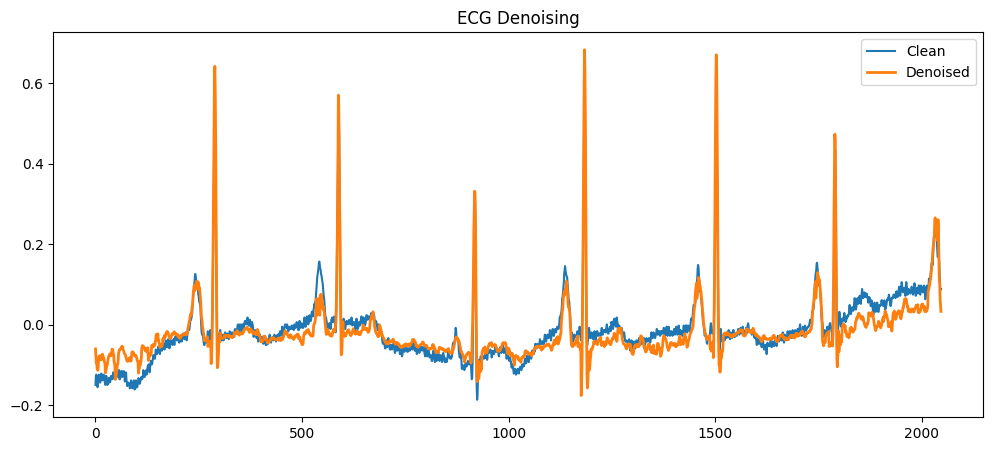

In [30]:
model.eval()

i = 100
noisy = X_test[i:i+1].to(device)

with torch.no_grad():
    denoised = model(noisy).cpu().numpy()[0,0]

clean = Y_test[i][0].numpy()
noisy = X_test[i][0].numpy()

plt.figure(figsize=(12,5))
plt.plot(clean, label="Clean")
# plt.plot(noisy, label="Noisy", alpha=0.6)
plt.plot(denoised, label="Denoised", linewidth=2)
plt.legend()
plt.title("ECG Denoising")
plt.show()

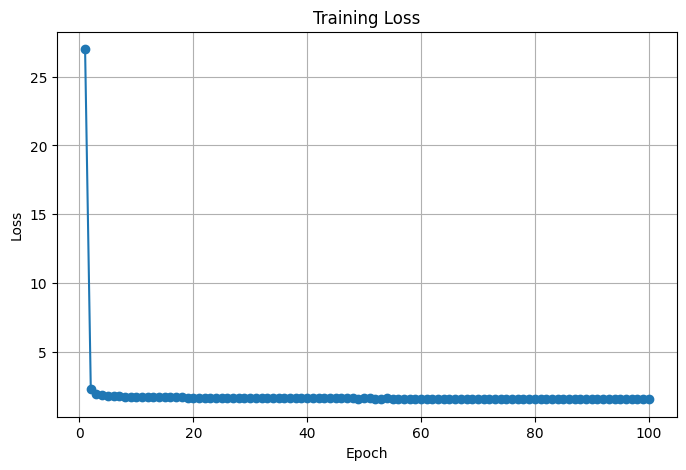

In [26]:
########### Plotting Training error vs Validation error with epochs ###########

plt.figure(figsize=(8,5))

plt.plot(range(1, N_ITERATIONS+1), train_loss, marker='o')

plt.title("Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [27]:
########### Classification ###########